# Tropical cyclone best tracks

HURDAT2 is the National Hurricane Center's best-track database: after each
season, forecasters reanalyse every tropical and subtropical cyclone and
record its centre position, maximum sustained wind, central pressure, and,
since 2004, wind radii, every six hours plus extra points at landfalls and
peaks. The Atlantic record starts in 1851 and the northeast and north-central
Pacific in 1949. The NHC publishes each basin as one fixed-format text file
and replaces it with a newly dated revision after each season; there is no
query interface.

This walkthrough pulls the whole Atlantic file in its 2026-02-27 revision
(1851 to 2025) and draws the 2024 season. It needs `usdata[pandas]` and
matplotlib, and downloads one 7 MB file in a few seconds.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-24T06:07:13+00:00
usdata 0.26.0; pandas 3.0.6


## Select

There is nothing to subset on the server, so the manifest names only a basin
and a revision. `basin` is `atlantic` or `pacific`; dates, places, and
variables are rejected rather than ignored, because none of them would change
which bytes arrive. Filter the parsed table locally instead.

Without `revision`, a first pull takes the newest file. This manifest names
the 2026-02-27 revision because the newest one, 2026-09-12, has two upstream
typos the reader refuses to guess at. Once pulled, the lockfile pins the file
either way.

In [2]:
print(manifest.read_text())

name: atlantic-best-tracks
sources:
  - dataset: noaa:hurdat2
    # One whole basin file. HURDAT2 has no query interface, so dates and
    # geographic filters are rejected; filter the parsed track table locally.
    params:
      basin: atlantic
      # The 2026-09-12 revision has two upstream typos the reader refuses to guess at.
      revision: 2026-02-27



## What arrives

The first pull downloads one text file and writes `dataset.lock.json` beside
the manifest, pinning its checksum. The filename carries the data span and
the revision date (`02272026` is 27 February 2026, written month first).

In [3]:
result = pull(manifest)
(item,) = result.fetched
print("File:", item.path.name)
print("Bytes:", item.provenance.size)
print("Source:", item.provenance.source_url)
print("Retrieved (UTC):", item.provenance.retrieved_at.isoformat(timespec="seconds"))
print("Checksum:", item.provenance.checksum)

File: hurdat2-1851-2025-02272026.txt
Bytes: 7082381
Source: https://www.nhc.noaa.gov/data/hurdat/hurdat2-1851-2025-02272026.txt
Retrieved (UTC): 2026-09-24T06:07:14+00:00
Checksum: sha256:1b9b0c7beed5b4505838658b1d30e159fc84330c60891a58cfcf43ae55c37202


## Open

`item.open()` picks the HURDAT2 reader from the dataset and returns one row
per best-track point. `time` is UTC. `latitude` and `longitude` are signed
decimal degrees, the source's hemisphere letters turned into signs.
`max_wind_kt` is the maximum sustained one-minute wind in knots and
`min_pressure_mb` the central pressure in millibars. `status` is the system's
type at that point (`HU` hurricane, `TS` tropical storm, `EX` extratropical,
and so on), and `record_identifier` marks special points, `L` for landfall.
The documented missing values (`-999`, and `-99` for an unassigned wind)
become NaN.

In [4]:
tracks = item.open()
print(f"{len(tracks):,} track points, {tracks['storm_id'].nunique():,} systems")
print(f"{tracks['time'].min():%Y-%m-%d} to {tracks['time'].max():%Y-%m-%d}")
print("Record identifiers:", tracks["record_identifier"].value_counts().to_dict())
columns = ["storm_id", "name", "time", "record_identifier", "status", "latitude", "longitude"]
tracks[[*columns, "max_wind_kt", "min_pressure_mb"]].tail()

55,605 track points, 2,004 systems
1851-06-25 to 2025-11-01
Record identifiers: {'L': 1175, 'I': 33, 'R': 11, 'P': 10, 'T': 9, 'S': 8, 'C': 5, 'W': 4, 'G': 1}


,storm_id,name,time,record_identifier,status,latitude,longitude,max_wind_kt,min_pressure_mb
55600,AL132025,MELISSA,2025-10-31 06:00:00+00:00,<NA>,HU,34.5,-65.5,75.0,972.0
55601,AL132025,MELISSA,2025-10-31 12:00:00+00:00,<NA>,EX,37.7,-62.1,75.0,972.0
55602,AL132025,MELISSA,2025-10-31 18:00:00+00:00,<NA>,EX,40.6,-58.9,70.0,972.0
55603,AL132025,MELISSA,2025-11-01 00:00:00+00:00,<NA>,EX,43.7,-56.0,70.0,971.0
55604,AL132025,MELISSA,2025-11-01 06:00:00+00:00,<NA>,EX,46.6,-51.3,65.0,968.0


Wind radii exist only from 2004, and the radius of maximum wind is mostly
missing before 2021:

In [5]:
has_radii = tracks.groupby(tracks["time"].dt.year)[["r34_ne_nm", "max_wind_radius_nm"]].count()
print(has_radii.loc[[2003, 2004, 2020, 2021]].to_string())

      r34_ne_nm  max_wind_radius_nm
time                               
2003          0                   2
2004        587                   9
2020        883                   7
2021        602                 602


## A first look

The 2024 season, each track point coloured by its Saffir-Simpson category.
The file has no coastline, but its 1,175 landfall points from 1851 onward,
drawn in grey, trace one.

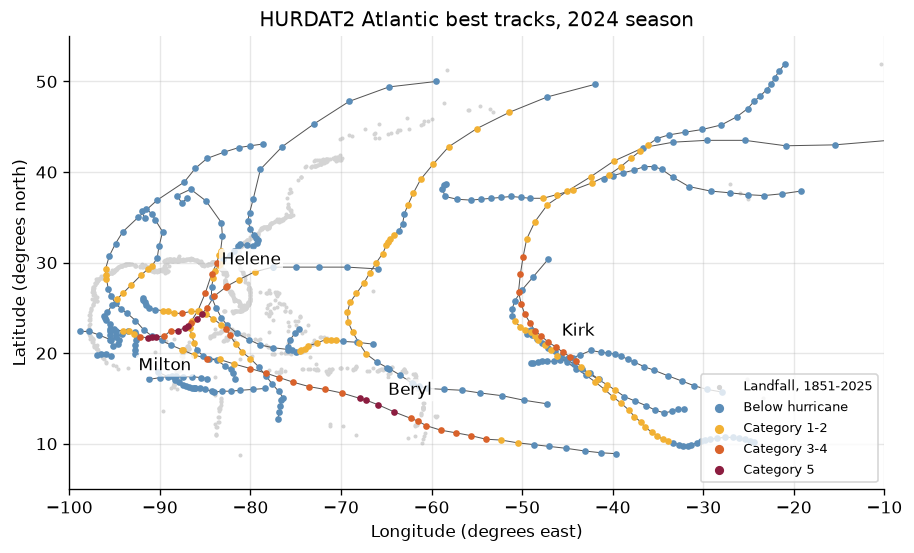

In [6]:
season = tracks[tracks["time"].dt.year == 2024]
landfalls = tracks[tracks["record_identifier"] == "L"]
scale = [
    (0, 64, "#5b8db8", "Below hurricane"),
    (64, 96, "#f2b134", "Category 1-2"),
    (96, 137, "#d9622b", "Category 3-4"),
    (137, 999, "#8c1d40", "Category 5"),
]
fig, ax = plt.subplots(layout="constrained")
ax.scatter(
    landfalls["longitude"], landfalls["latitude"], s=2, color="#d4d4d4", label="Landfall, 1851-2025"
)
for _, storm in season.groupby("storm_id"):
    ax.plot(storm["longitude"], storm["latitude"], color="#555555", linewidth=0.6)
for low, high, color, label in scale:
    points = season[season["max_wind_kt"].ge(low) & season["max_wind_kt"].lt(high)]
    ax.scatter(points["longitude"], points["latitude"], s=9, color=color, label=label, zorder=3)
labels = {"BERYL": (6, 6), "HELENE": (6, 6), "KIRK": (8, 4), "MILTON": (-8, -20)}
for name, offset in labels.items():
    peak = season.loc[season.loc[season["name"] == name, "max_wind_kt"].idxmax()]
    where = (peak["longitude"], peak["latitude"])
    box = {"boxstyle": "round,pad=0.15", "fc": "white", "ec": "none", "alpha": 0.8}
    ax.annotate(name.title(), where, xytext=offset, textcoords="offset points", bbox=box)
ax.set_xlim(-100, -10)
ax.set_ylim(5, 55)
ax.set_aspect("equal")
ax.set_xlabel("Longitude (degrees east)")
ax.set_ylabel("Latitude (degrees north)")
ax.set_title("HURDAT2 Atlantic best tracks, 2024 season")
ax.legend(loc="lower right", fontsize=8, markerscale=1.5)
plt.show()

In [7]:
strongest = season.groupby("name").agg(
    max_wind_kt=("max_wind_kt", "max"),
    min_pressure_mb=("min_pressure_mb", "min"),
    landfall_points=("record_identifier", lambda s: (s == "L").sum()),
)
hurricanes = (strongest["max_wind_kt"] >= 64).sum()
print(f"{season['storm_id'].nunique()} systems in 2024; {hurricanes} reached hurricane strength")
beryl = season[(season["name"] == "BERYL") & (season["max_wind_kt"] >= 137)].iloc[0]
where = f"{beryl['latitude']}° N, {-beryl['longitude']}° W"
print(f"Beryl first at category 5: {beryl['time']:%d %b %H:%M} UTC at {where}")
helene = season[(season["name"] == "HELENE") & (season["record_identifier"] == "L")].iloc[0]
print(f"Helene landfall: {helene['time']:%d %b %H:%M} UTC, {helene['max_wind_kt']:.0f} kt")
strongest.sort_values("max_wind_kt", ascending=False).head(6)

18 systems in 2024; 11 reached hurricane strength
Beryl first at category 5: 02 Jul 00:00 UTC at 13.5° N, 64.1° W
Helene landfall: 27 Sep 03:10 UTC, 120 kt


,max_wind_kt,min_pressure_mb,landfall_points
name,,,
MILTON,155.0,895.0,1
BERYL,145.0,932.0,3
KIRK,130.0,928.0,0
HELENE,120.0,939.0,1
RAFAEL,105.0,954.0,1
LESLIE,90.0,970.0,0


Beryl reached category 5 in the Caribbean on 2 July, the earliest in the
year any Atlantic hurricane has; Milton reached 155 kt and 895 mb over the
Gulf of Mexico in October. Kirk, a category 4, has no landfall point. Helene's
single landfall point is its category 4 landfall in Florida's Big Bend,
which the [storm surge study](https://usdata.dev/studies/storm-surge/) times
against the tide gauge at Cedar Key.

## Pin and cite

`verify` checks the cached file against the lockfile's checksum. Keep the
manifest, lockfile, and cached bytes: the NHC replaces this file with a new
revision each season, and a checksum cannot recreate a file that is no longer
published. `pull(manifest, force=True)` moves to the current revision on
purpose. The citation below is what a methods section needs, and
`usdata cite dataset.yaml` prints the same.

In [8]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

noaa:hurdat2
  Landsea, C. W. and J. L. Franklin, 2013: Atlantic Hurricane Database Uncertainty and Presentation of a New Database Format. Mon. Wea. Rev., 141, 3576-3592
  homepage: https://www.nhc.noaa.gov/data/#hurdat
  license: US Government Work (public domain)
  terms: https://www.weather.gov/disclaimer
  retrieved: 2026-09-24; 1 checksummed asset (7,082,381 bytes) pinned by usdata 0.26.0
  sources: 1


## What was awkward

- The newest revision, 2026-09-12, has two upstream typos the reader will not
  guess at, so this manifest has to name the previous revision.
- There is no way to ask for one season or one storm. Every pull is the whole
  7 MB basin file, and all filtering happens after parsing.
- A landfall row is not one landfall event per storm: a storm crossing
  several coasts has several, and a landfall point's category is the
  intensity at that point.
- The record is not uniform in time. Wind radii start in 2004, the radius of
  maximum wind in 2021 (with a few hundred earlier Atlantic points back-filled),
  and the early decades undercount storms and underestimate intensities, so
  counts and extremes across eras are not directly comparable.
- The file has no coastline or map, so a map needs another source or, as
  here, the file's own landfall points.
- Revision dates in filenames are month first (`02272026`), and the
  [HURDAT2 guide](https://docs.usdata.dev/providers/noaa-hurdat2/) notes that
  sorting them as text puts some revisions in the wrong order.